In [309]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal, stats
from scipy.signal import butter, filtfilt, welch
import os
import glob
from pathlib import Path

import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

normal_path = 'N_TXT'
abnormal_path = 'A_TXT'

# Activity mapping
activity_map = {
    'mar': 'Walking (March)',
    'pie': 'Leg Extension',
    'sen': 'Knee Flexion'
}

# Channel names
channels = ['RF', 'BF', 'VM', 'ST', 'FX']

In [310]:
def get_subject_info(filename):
    """Extract subject number, activity type, and group from filename."""
    # Example: 1Amar.txt -> subject=1, activity=mar, group=A(abnormal)
    basename = os.path.basename(filename).replace('.txt', '')
    
    # Find where the letter starts (subject number)
    subject_num = ''
    idx = 0
    for i, c in enumerate(basename):
        if c.isalpha():
            subject_num = basename[:i]
            idx = i
            break
    
    # Group is next letter (N or A)
    group = basename[idx]
    
    # Activity is from index+1 to end
    activity = basename[idx+1:]
    
    return int(subject_num), group, activity

# Load all data files
data_files = []
for group_type, group_path, group_label in [('N', normal_path, 'Normal'), 
                                             ('A', abnormal_path, 'Abnormal')]:
    files = sorted(glob.glob(os.path.join(group_path, '*.txt')))
    for filepath in files:
        subject_num, _, activity = get_subject_info(filepath)
        print(f"Loading file: {filepath} | Subject: {subject_num} | Group: {group_label} | Activity: {activity_map.get(activity, activity)}")
        
        data_files.append({
            'filepath': filepath,
            'group': group_label,
            'subject': subject_num,
            'activity': activity,
            'activity_name': activity_map.get(activity, activity),
        })

# Create DataFrame for easy access
df_info = pd.DataFrame(data_files)

Loading file: N_TXT\10Nmar.txt | Subject: 10 | Group: Normal | Activity: Walking (March)
Loading file: N_TXT\10Npie.txt | Subject: 10 | Group: Normal | Activity: Leg Extension
Loading file: N_TXT\10Nsen.txt | Subject: 10 | Group: Normal | Activity: Knee Flexion
Loading file: N_TXT\11Nmar.txt | Subject: 11 | Group: Normal | Activity: Walking (March)
Loading file: N_TXT\11Npie.txt | Subject: 11 | Group: Normal | Activity: Leg Extension
Loading file: N_TXT\11Nsen.txt | Subject: 11 | Group: Normal | Activity: Knee Flexion
Loading file: N_TXT\1Nmar.txt | Subject: 1 | Group: Normal | Activity: Walking (March)
Loading file: N_TXT\1Npie.txt | Subject: 1 | Group: Normal | Activity: Leg Extension
Loading file: N_TXT\1Nsen.txt | Subject: 1 | Group: Normal | Activity: Knee Flexion
Loading file: N_TXT\2Nmar.txt | Subject: 2 | Group: Normal | Activity: Walking (March)
Loading file: N_TXT\2Npie.txt | Subject: 2 | Group: Normal | Activity: Leg Extension
Loading file: N_TXT\2Nsen.txt | Subject: 2 | Gro

In [311]:
df_info

,filepath,group,subject,activity,activity_name
0,N_TXT\10Nmar.txt,Normal,10,mar,Walking (March)
1,N_TXT\10Npie.txt,Normal,10,pie,Leg Extension
2,N_TXT\10Nsen.txt,Normal,10,sen,Knee Flexion
3,N_TXT\11Nmar.txt,Normal,11,mar,Walking (March)
4,N_TXT\11Npie.txt,Normal,11,pie,Leg Extension
...,...,...,...,...,...
61,A_TXT\8Apie.txt,Abnormal,8,pie,Leg Extension
62,A_TXT\8Asen.txt,Abnormal,8,sen,Knee Flexion
63,A_TXT\9Amar.txt,Abnormal,9,mar,Walking (March)
64,A_TXT\9Apie.txt,Abnormal,9,pie,Leg Extension


In [312]:
def load_emg_file(filepath):
    """Load EMG data from txt file."""
    data = np.genfromtxt(filepath,skip_header=8,invalid_raise=False)
    df = pd.DataFrame(data[:, :5], columns=channels)
    return df

In [313]:
def plot_emg_signals(subject_label, group_label, activity):
    """Plot all 5 channels for a given EMG file."""
    filepath = df_info[(df_info['subject'] == subject_label) & (df_info['group'] == group_label) & (df_info['activity'] == activity)]['filepath'].iloc[0]
    print(filepath)
    df = load_emg_file(filepath)

    title = f"{group_label} | {activity_map.get(activity, activity)}"
    
    plt.figure(figsize=(15, 10))
    plt.suptitle(title, fontsize=16, fontweight='bold')
    
    for i, channel in enumerate(channels):
        plt.subplot(len(channels), 1, i + 1)
        plt.plot(df.index, df[channel], label=channel)
        plt.ylabel(channel, fontsize=12, fontweight='bold', rotation=0, labelpad=20)
        if i == len(channels) - 1:
            plt.xlabel('Time (samples)', fontsize=12, fontweight='bold')
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

### Normal Samples

N_TXT\11Nmar.txt


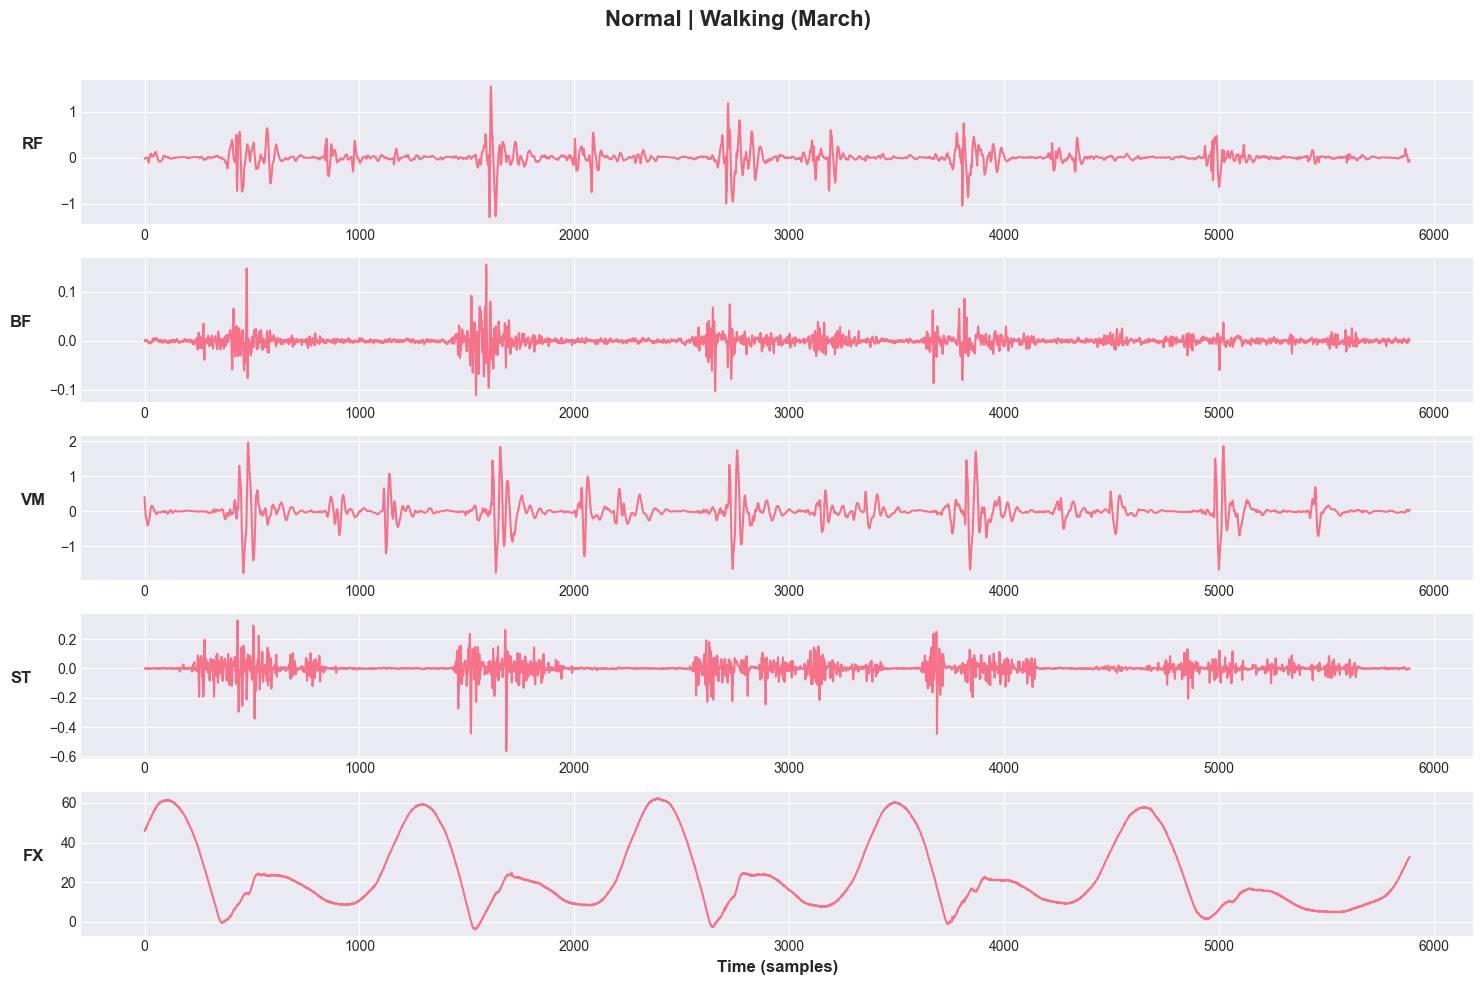

In [314]:
plot_emg_signals(11, 'Normal', 'mar')

N_TXT\1Nmar.txt


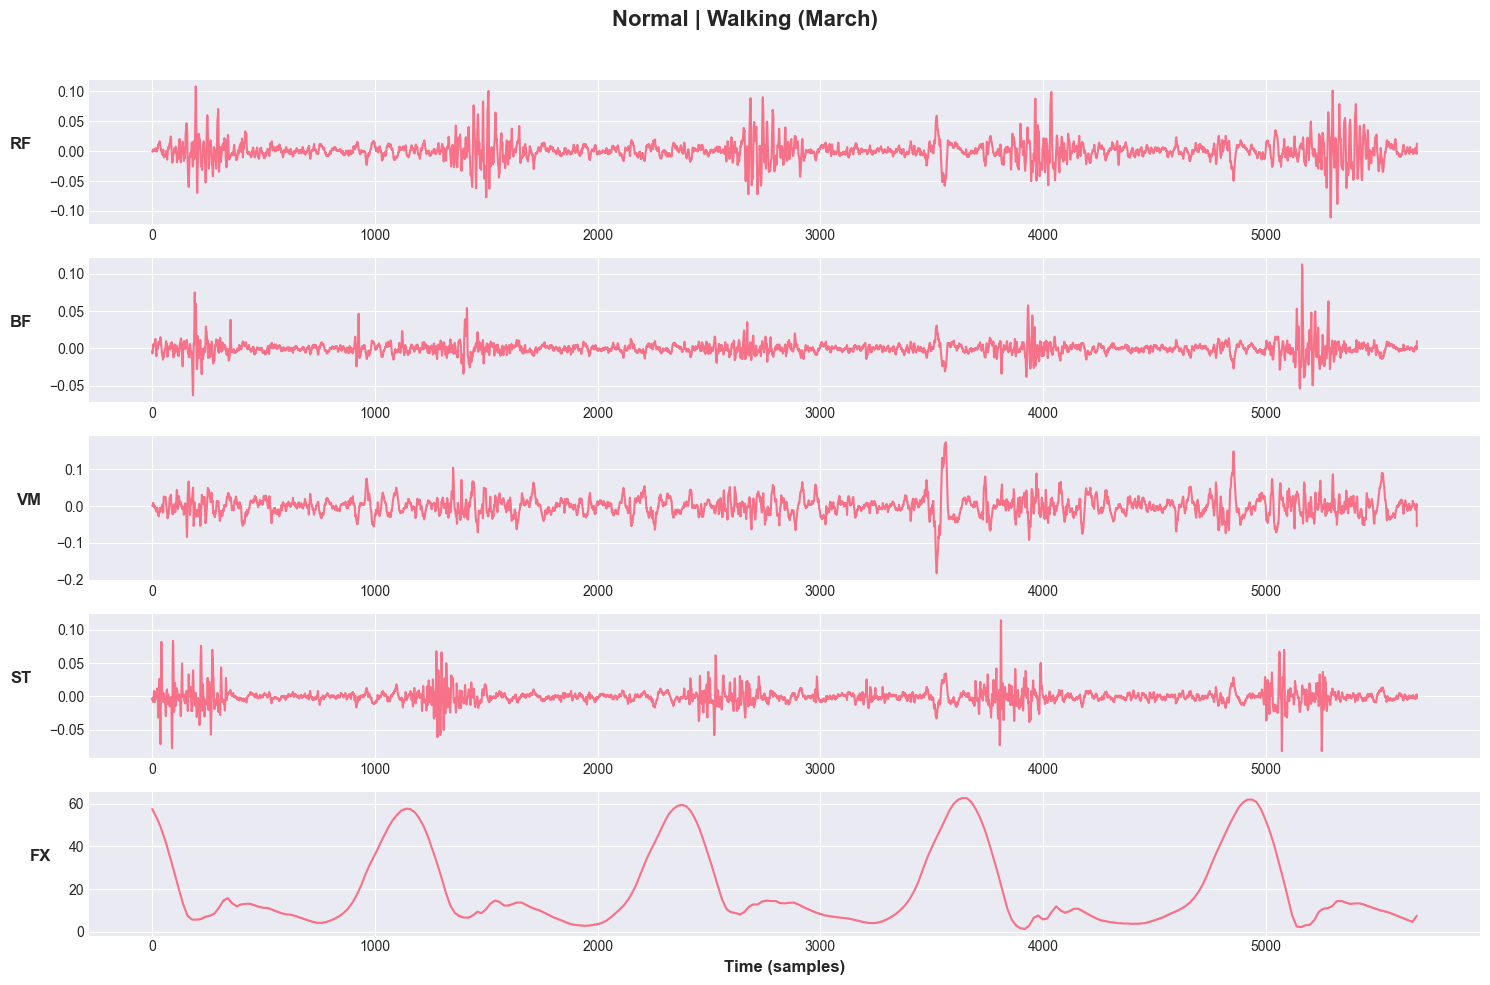

In [315]:
plot_emg_signals(1, 'Normal', 'mar')

N_TXT\11Npie.txt


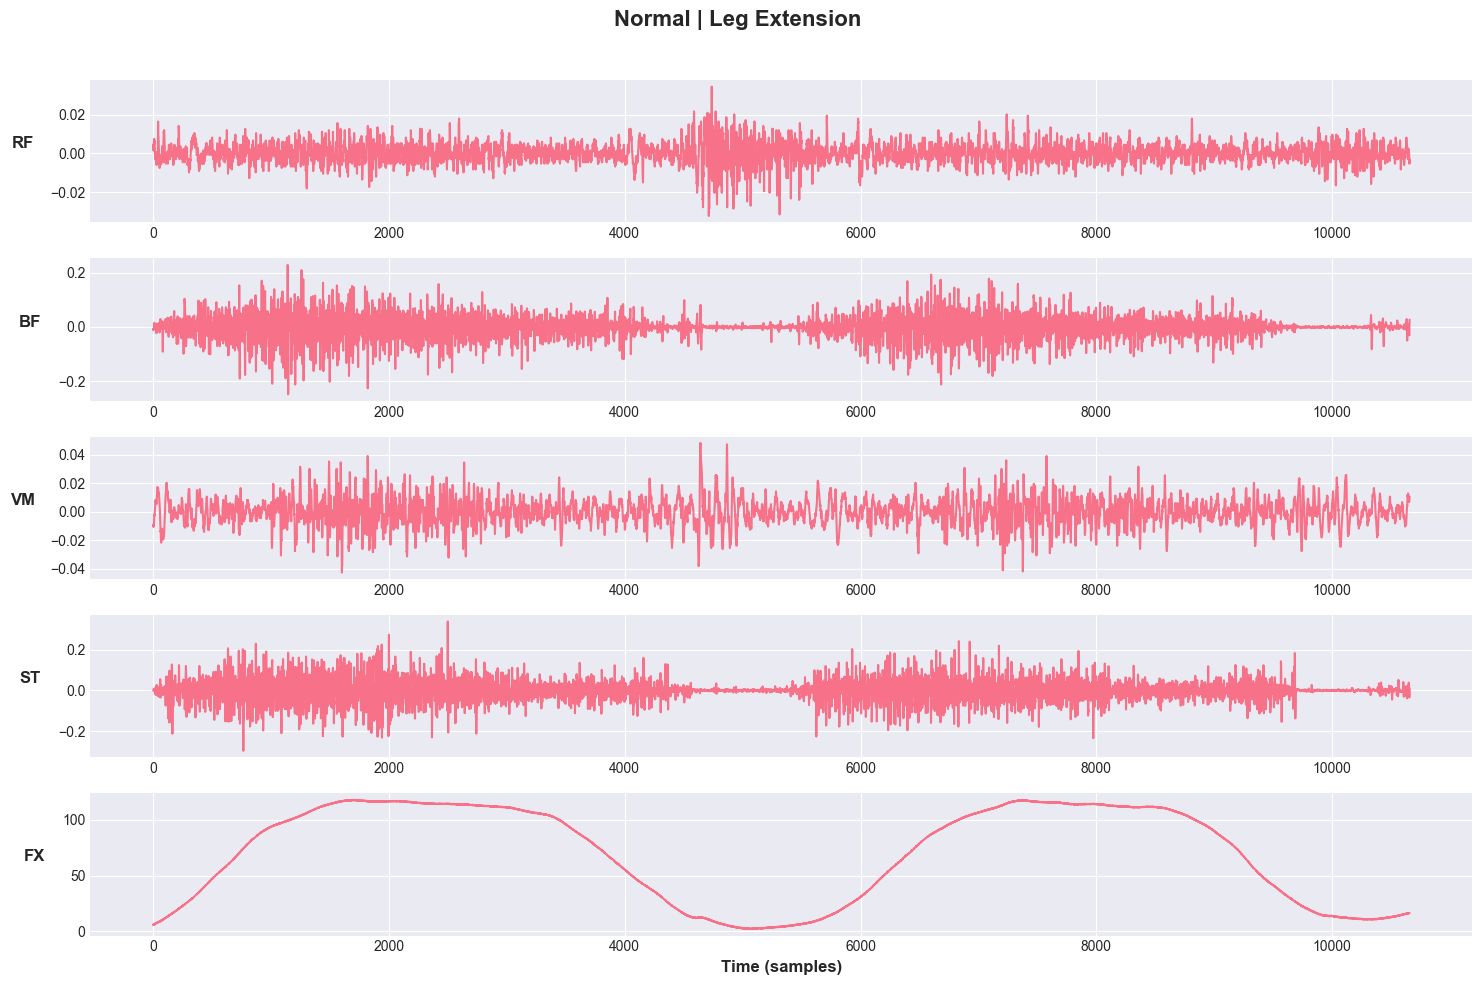

In [316]:
plot_emg_signals(11,'Normal', 'pie')

N_TXT\1Npie.txt


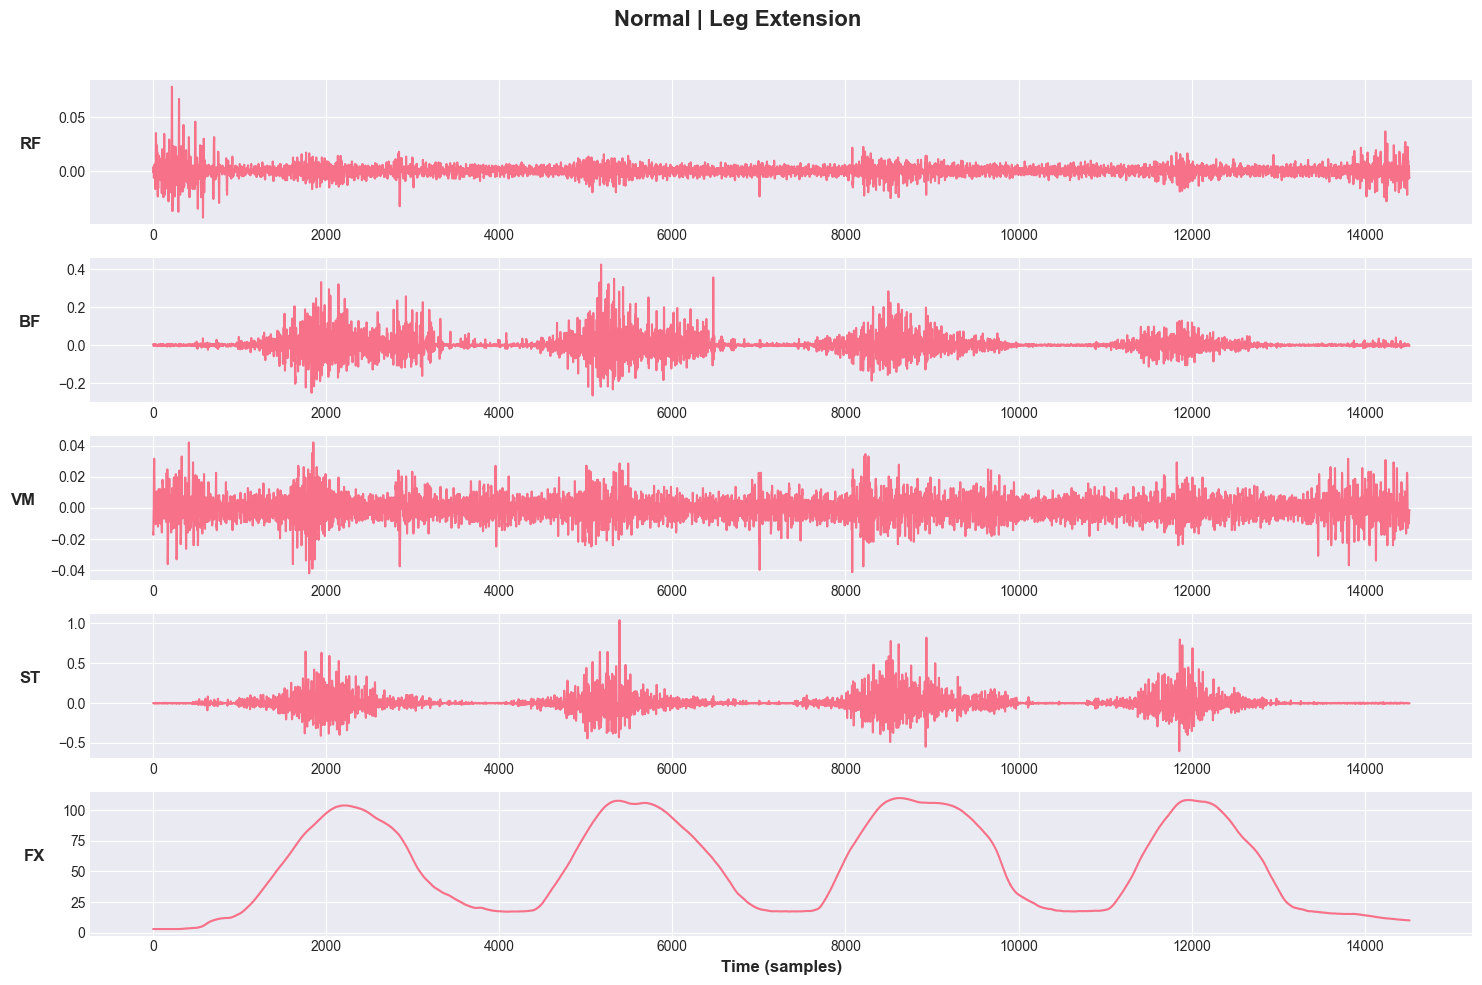

In [317]:
plot_emg_signals(1,'Normal', 'pie')

N_TXT\11Nsen.txt


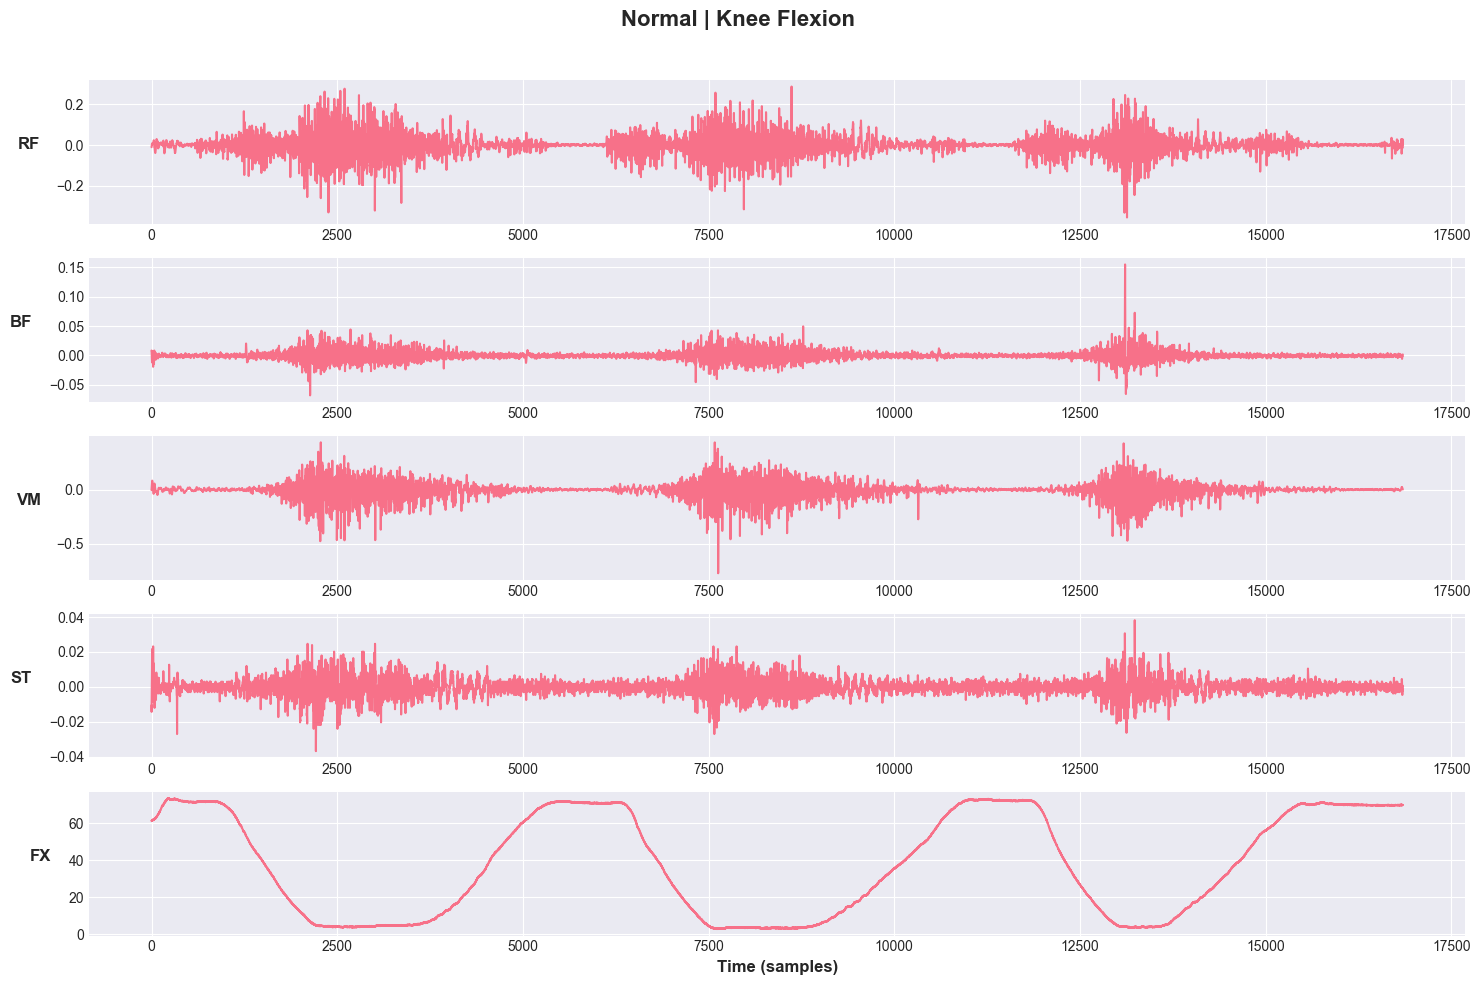

In [318]:
plot_emg_signals(11, 'Normal', 'sen')

N_TXT\1Nsen.txt


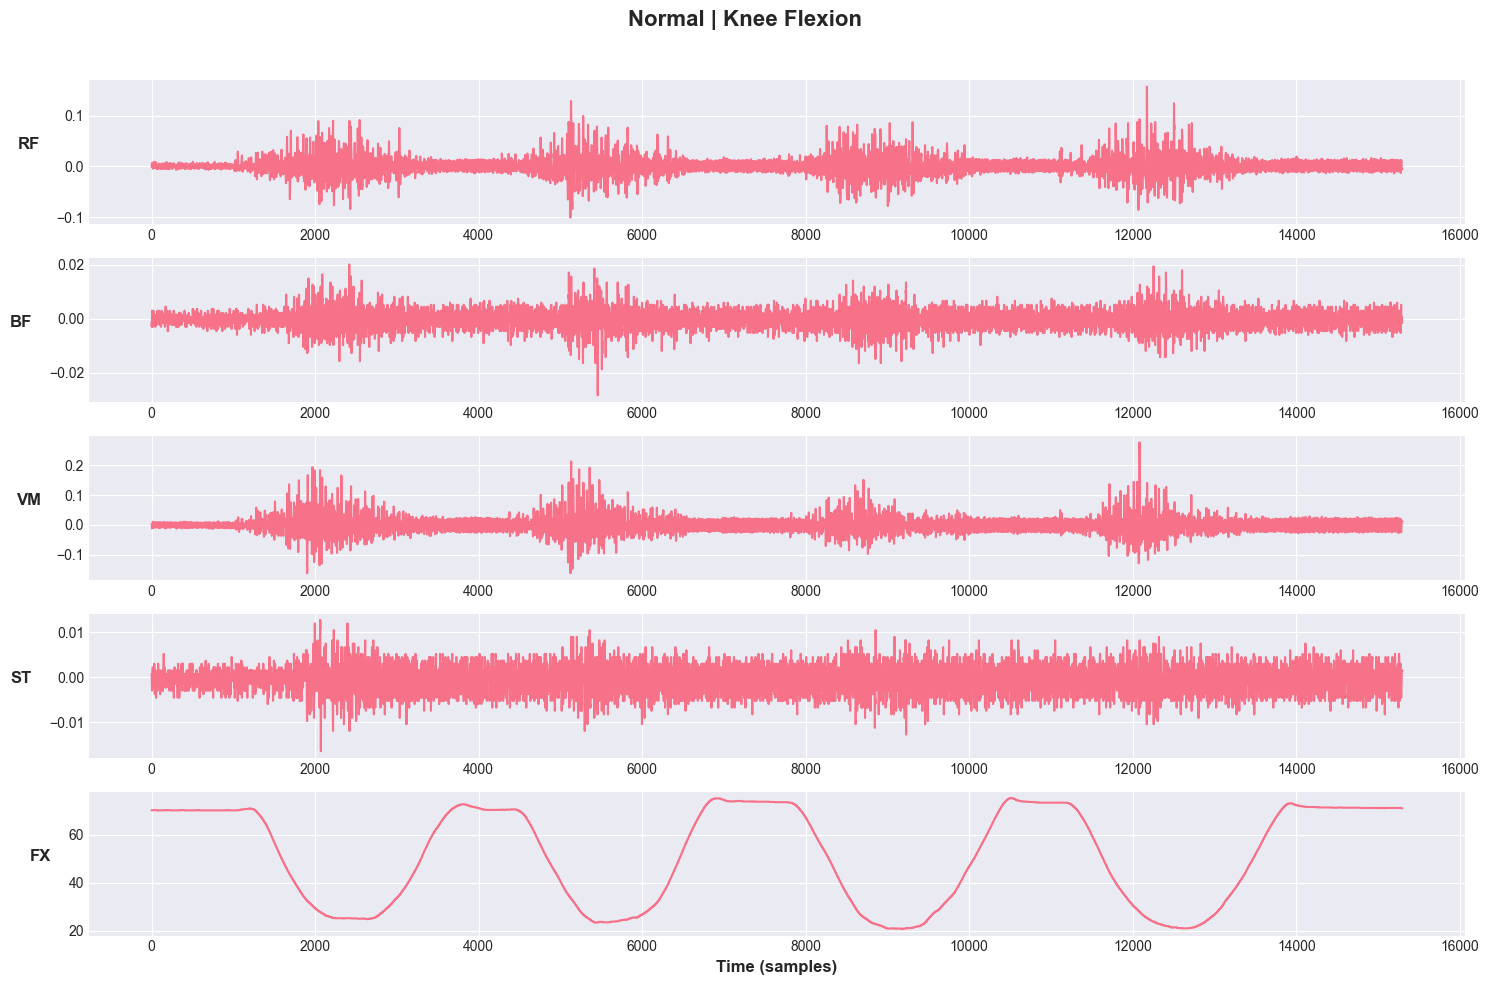

In [319]:
plot_emg_signals(1, 'Normal', 'sen')

### Abnormal Samples

A_TXT\11Amar.txt


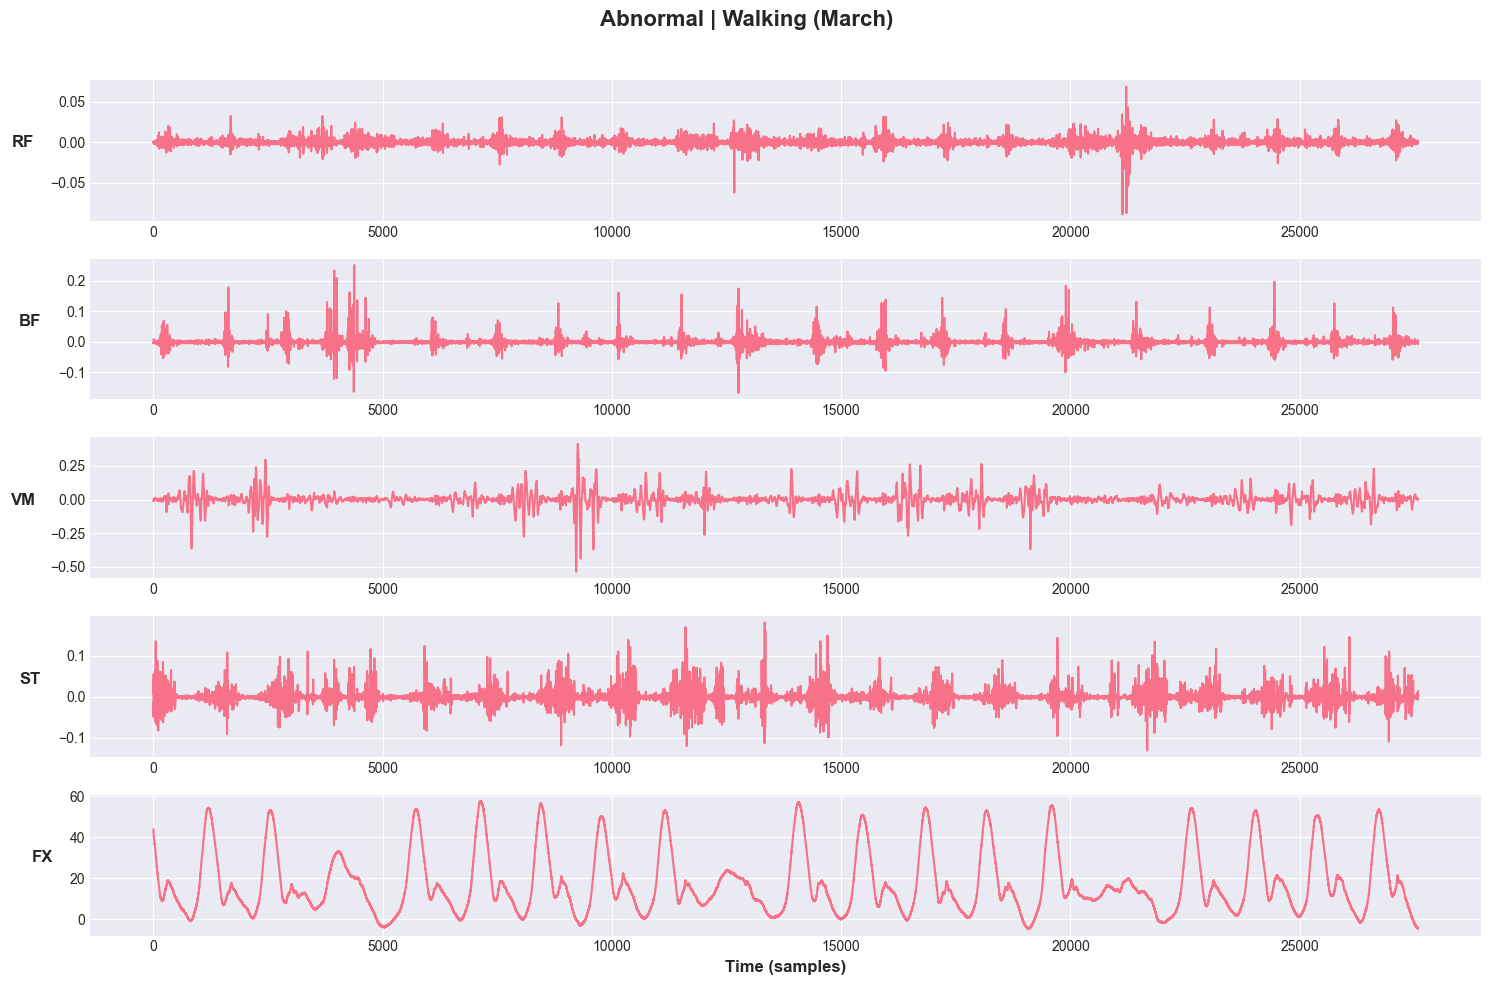

In [320]:
plot_emg_signals(11, 'Abnormal', 'mar')

A_TXT\1Amar.txt


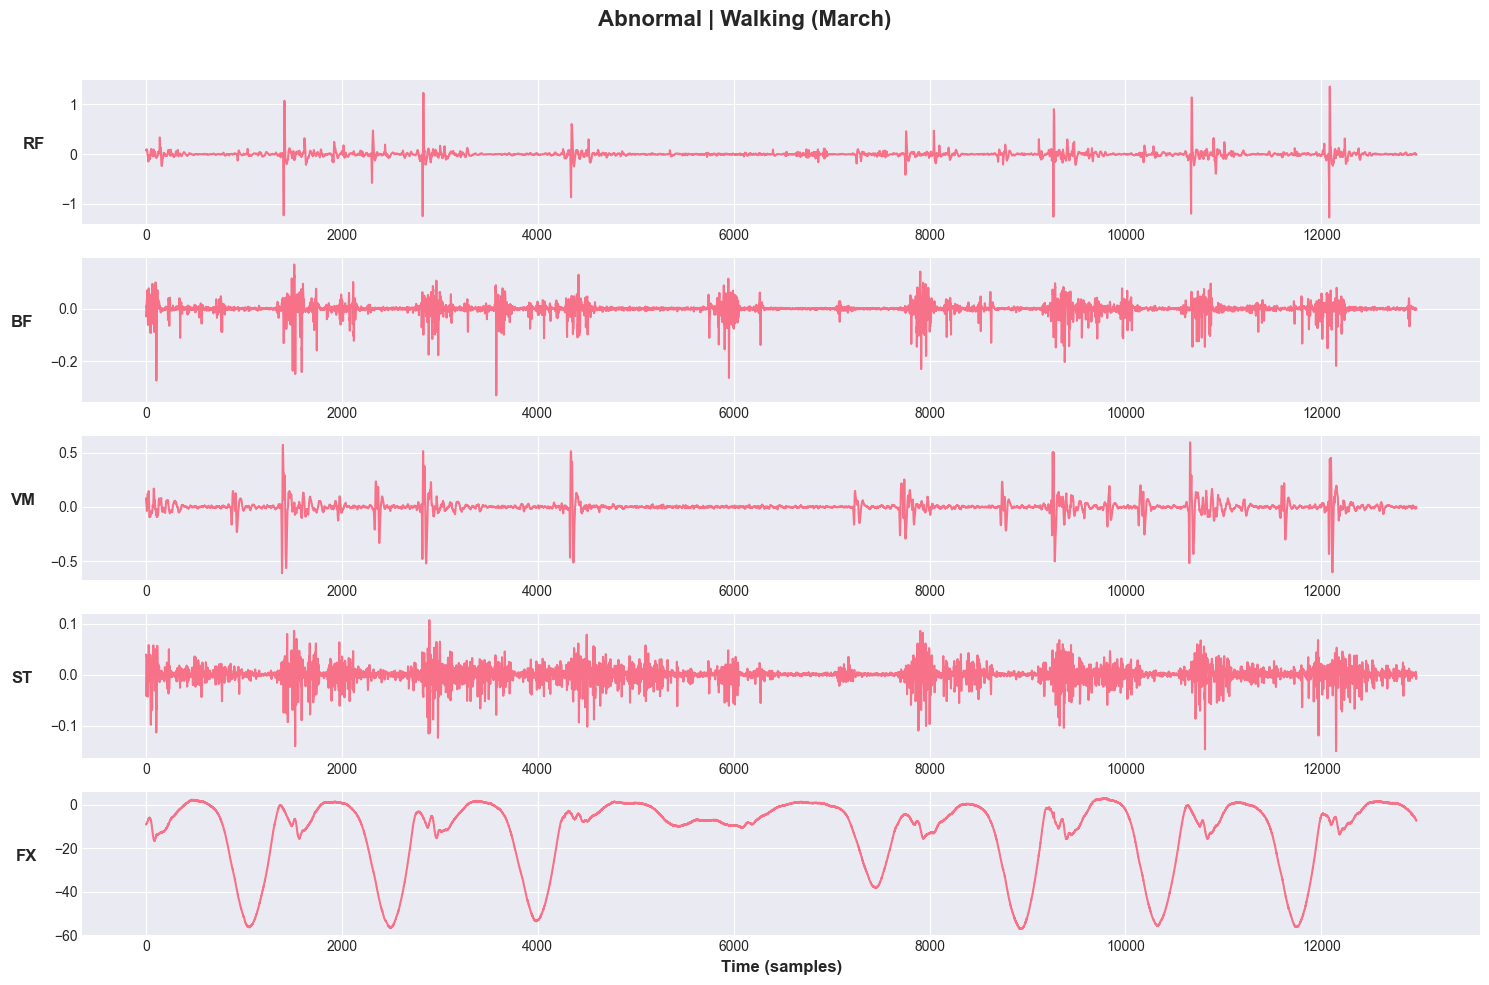

In [321]:
plot_emg_signals(1, 'Abnormal', 'mar')

A_TXT\11Apie.txt


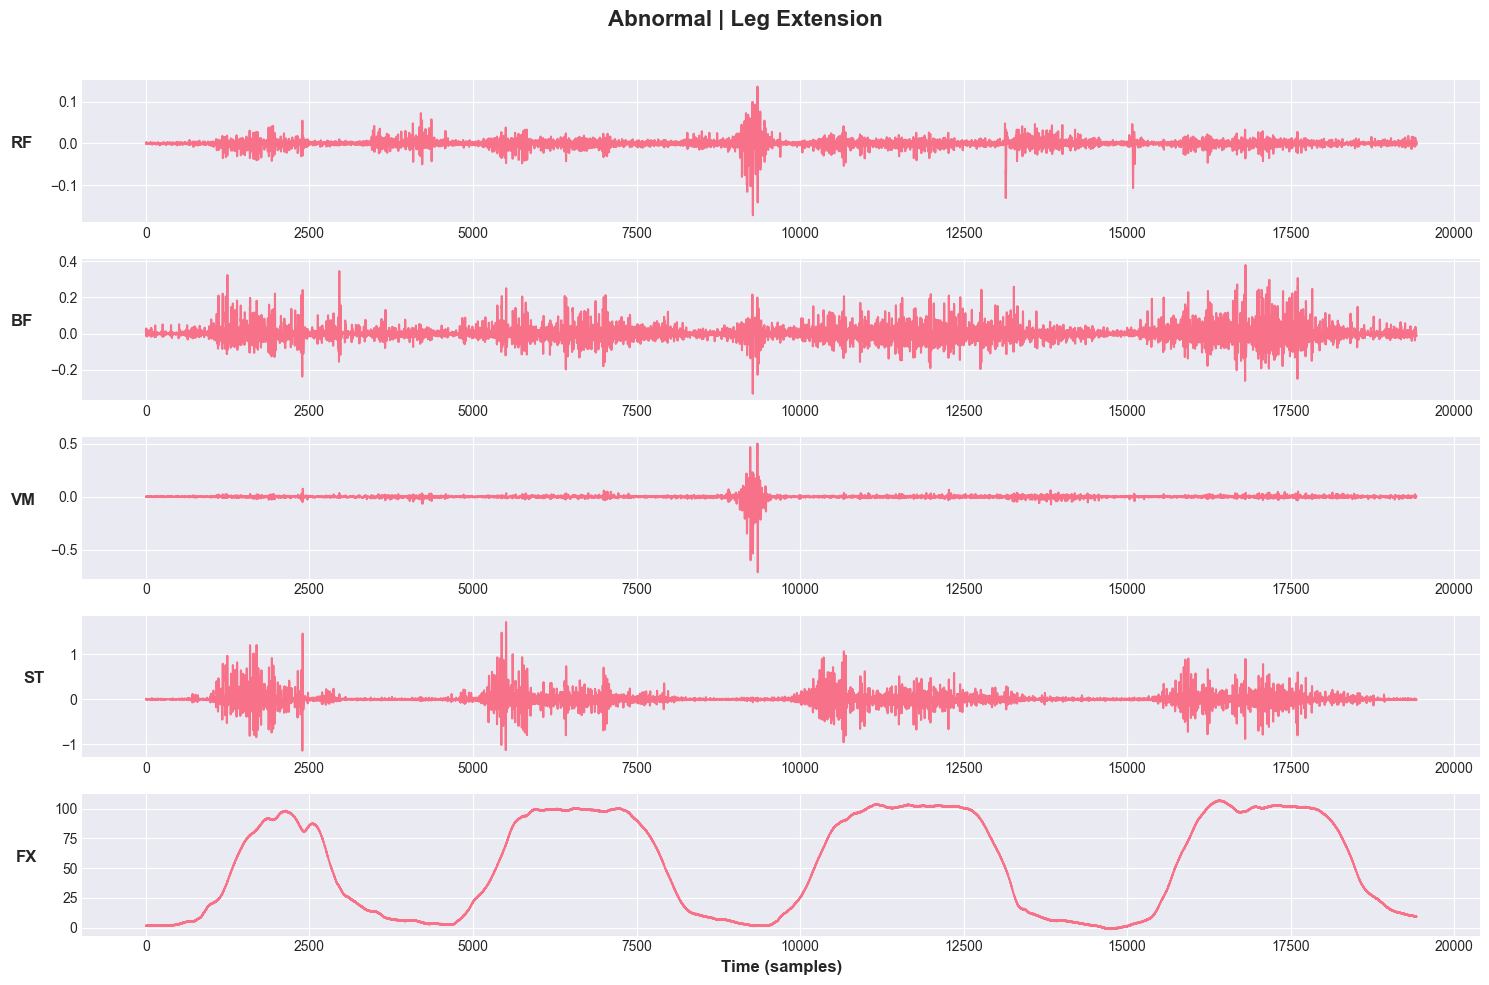

In [322]:
plot_emg_signals(11, 'Abnormal', 'pie')

A_TXT\1Amar.txt


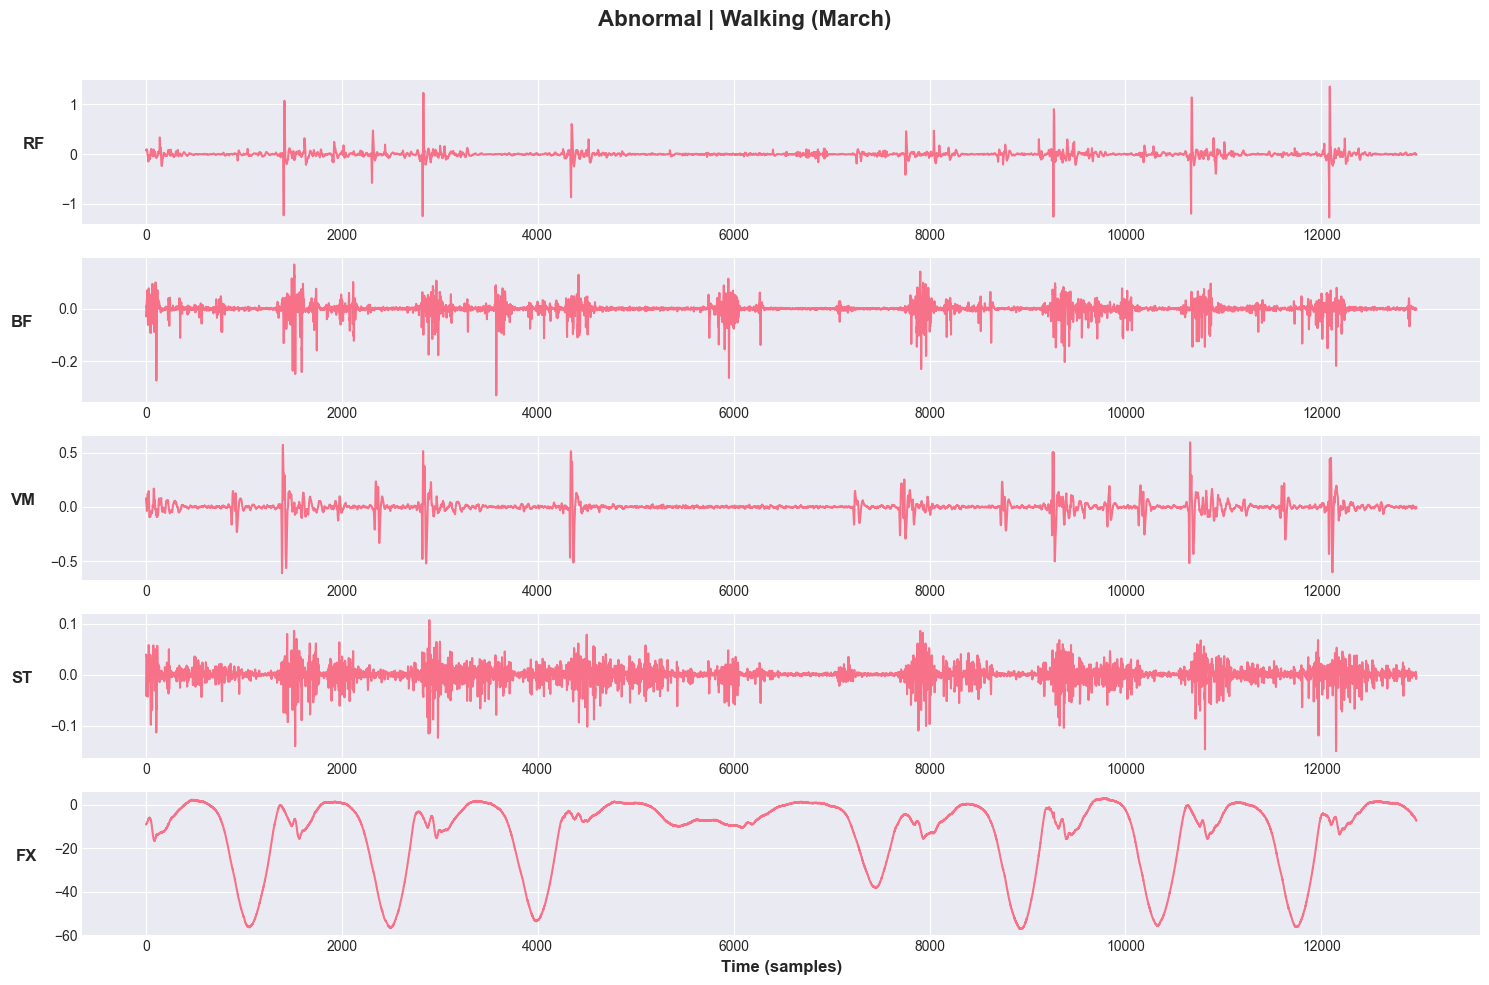

In [323]:
plot_emg_signals(1, 'Abnormal', 'mar')

A_TXT\11Asen.txt


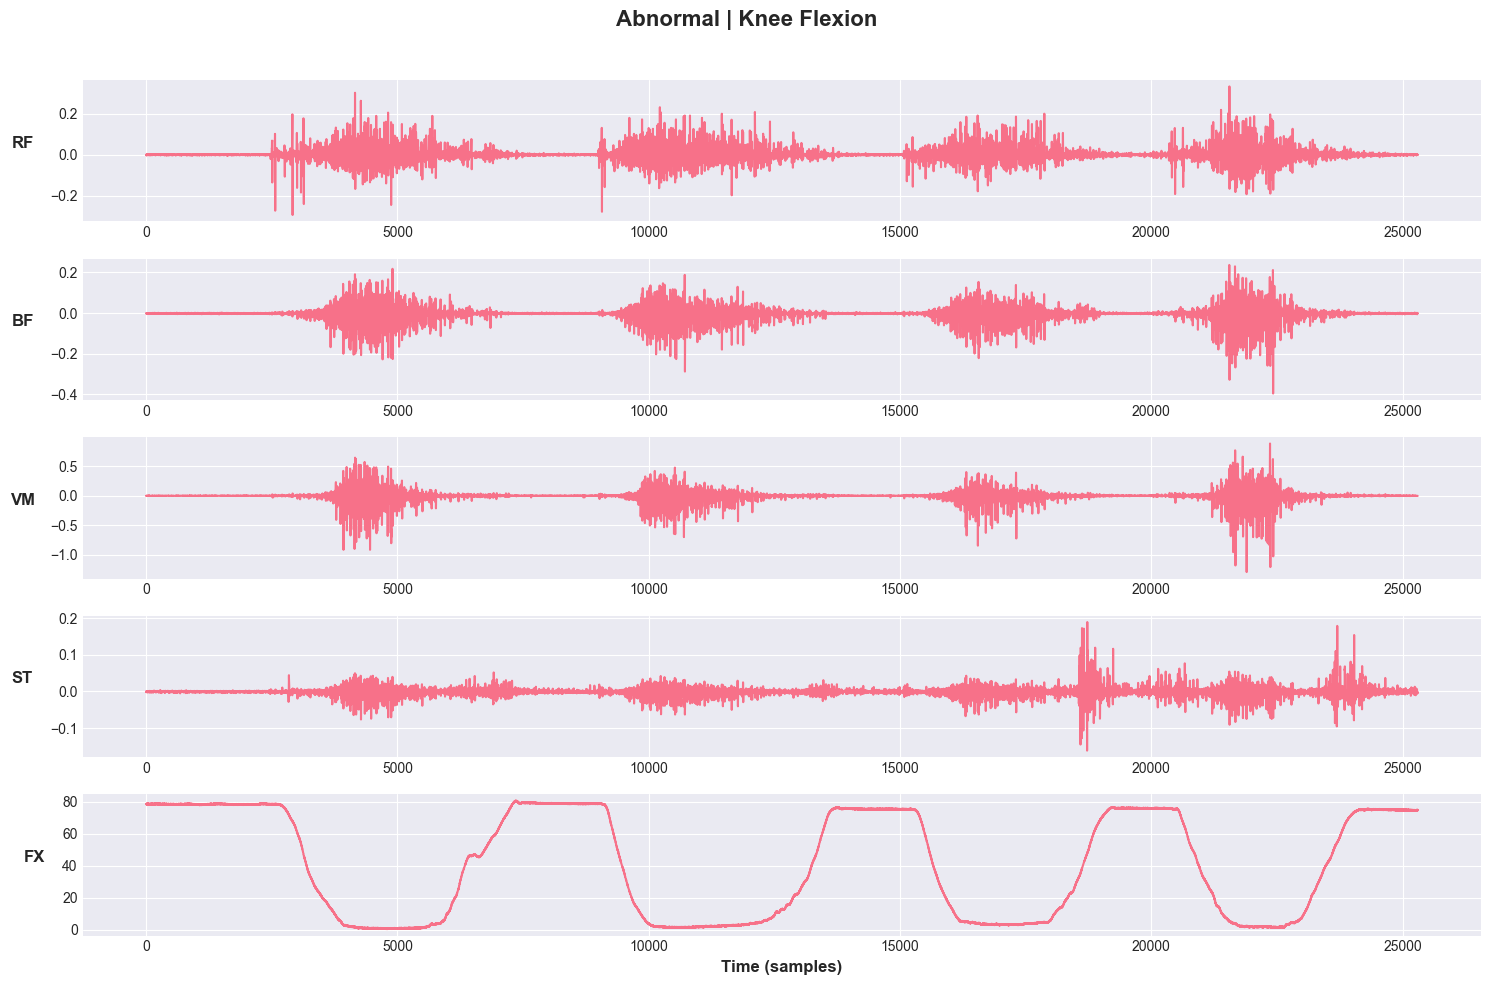

In [324]:
plot_emg_signals(11, 'Abnormal', 'sen')

A_TXT\1Asen.txt


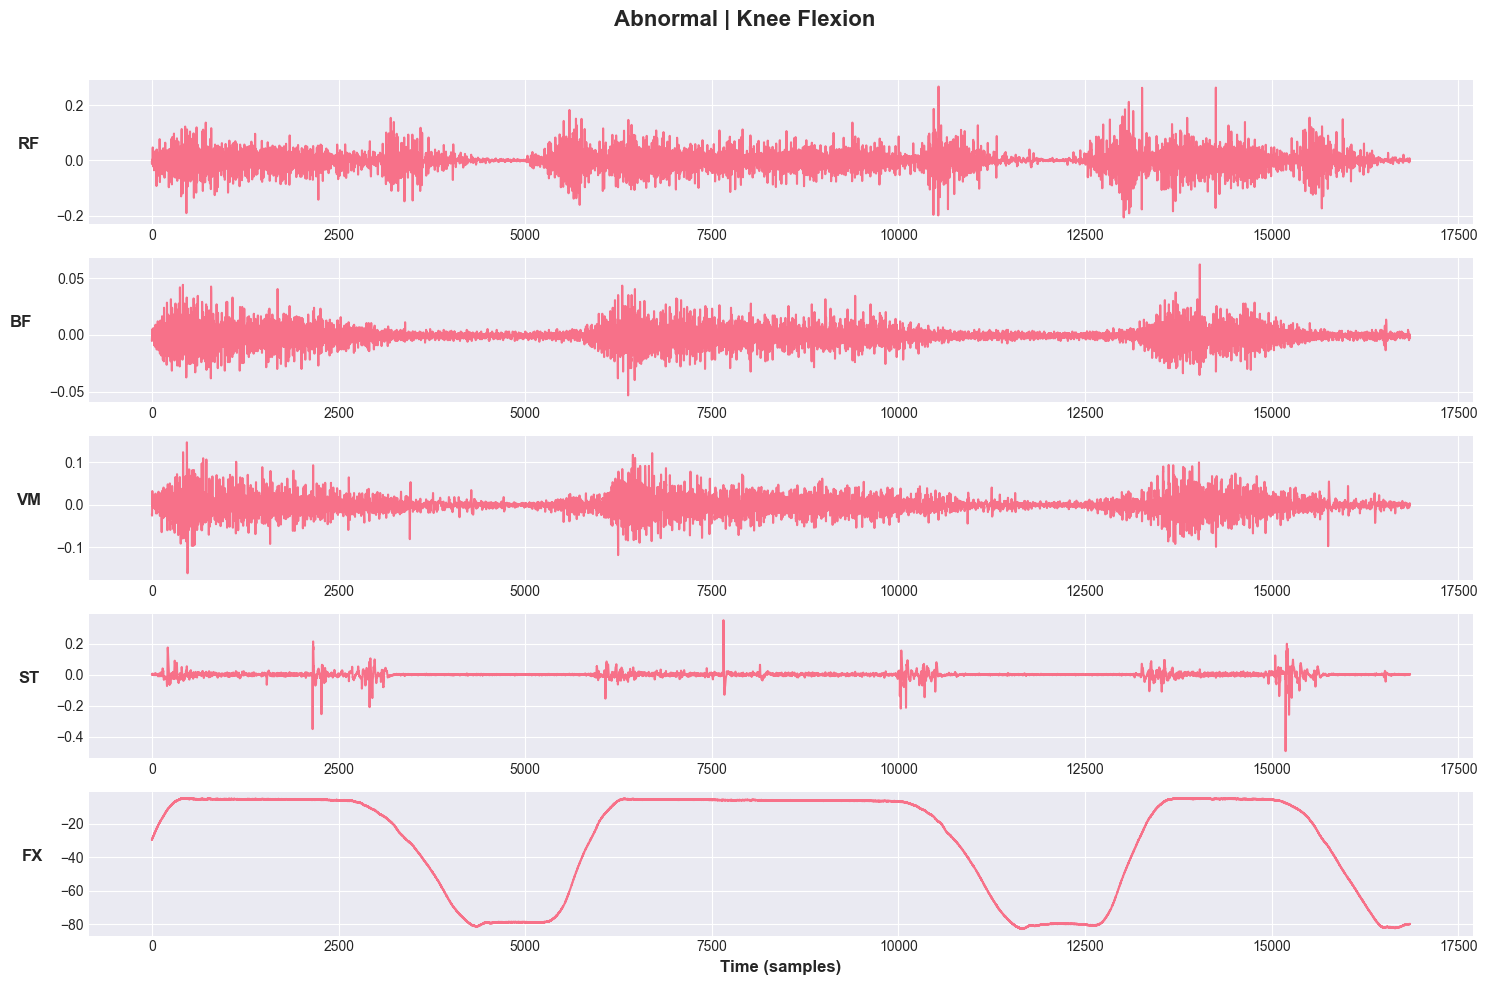

In [325]:
plot_emg_signals(1, 'Abnormal', 'sen')

## Processing

In [326]:
def plot_difference(emg, emg_filtered, channel='RF'):
    # Plot original vs filtered signals for one channel
    channel_index = channels.index(channel)
    plt.figure(figsize=(15, 6))
    plt.subplot(2, 1, 1)
    plt.plot(emg.index, emg.iloc[:, channel_index], label=f'Original {channel}', color='blue')
    plt.title(f'Original EMG Signal ({channel} Channel)', fontsize=12)
    plt.ylabel(channel, fontsize=12, rotation=0, labelpad=20)
    plt.legend()
    plt.subplot(2, 1, 2)
    plt.plot(emg_filtered.index, emg_filtered.iloc[:, channel_index], label=f'Filtered {channel}', color='orange')
    plt.title(f'Filtered EMG Signal ({channel} Channel)', fontsize=12)
    plt.ylabel(channel, fontsize=12, rotation=0, labelpad=20)
    plt.legend()

#### 1- high-pass Butterworth filter

And this helps us to remove the movement of the body and thus focus on the analysis and the minutes and remove any drift
Its purpose is to reduce low frequencies (low-frequency noise) i.e. here the cutting frequency = **20 Hz**

In [327]:
def apply_highpass(data: np.ndarray, fs: float = 1000.0, cutoff: float = 20.0, order: int = 4):
    """Apply a high-pass Butterworth filter to EMG data."""
    
    nyq = 0.5 * fs
    norm_cutoff = cutoff / nyq
    b, a = signal.butter(order, norm_cutoff, btype="highpass")
    df_filtered = pd.DataFrame(signal.filtfilt(b, a, data, axis=0))
    return df_filtered

In [328]:
emg = load_emg_file(r"A_TXT\1Asen.txt")
emg_filtered = apply_highpass(emg.values)

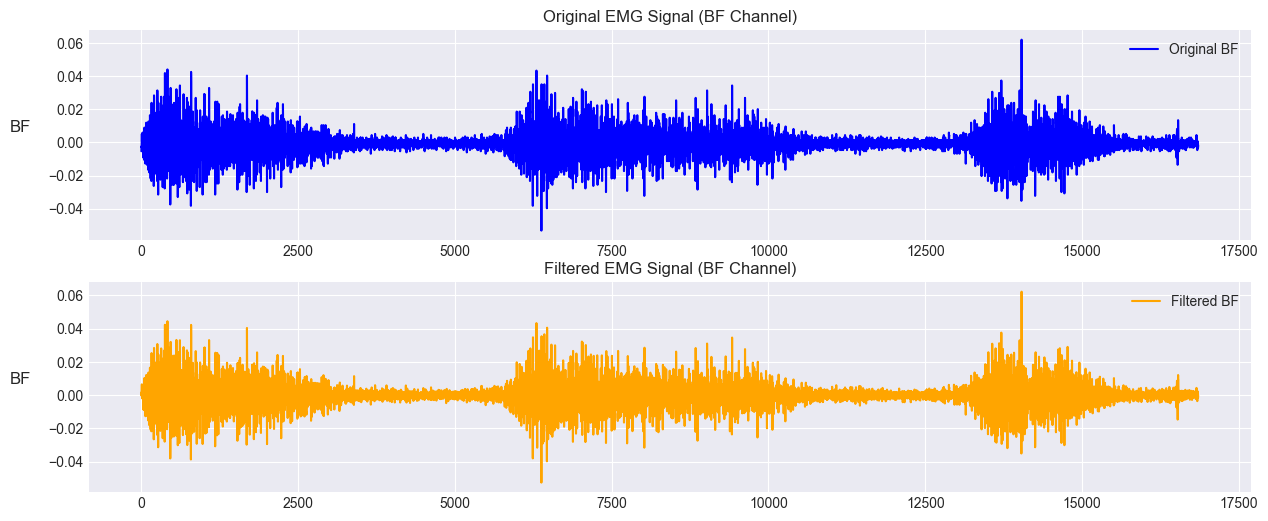

In [329]:
plot_difference(emg, emg_filtered, channel='BF')

#### 2 - Taking absolute value

The goal is to convert the signal to positive values only and represent the signal strength instead of the remaining vector.

In [330]:
def rectify(data: np.ndarray):
    """Rectify EMG signal by taking the absolute value."""
    return pd.DataFrame(np.abs(data))

In [331]:
emg = load_emg_file(r"N_TXT\1Nsen.txt")
emg_filtered = rectify(emg.values)

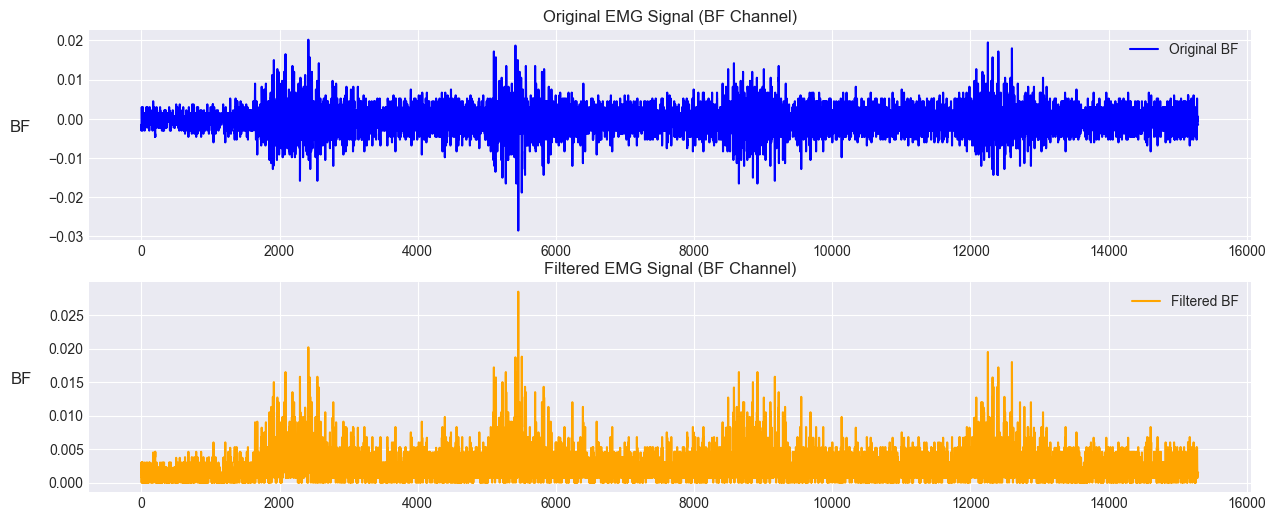

In [332]:
plot_difference(emg, emg_filtered, channel='BF')

#### 3 - low-pass Butterworth filter

The purpose of this is to smooth the signal, which means that we will make a filter (Butterworth 2nd order (Cutoff = 3–6 Hz).



In [333]:
def apply_lowpass(data: np.ndarray, fs: float = 1000.0, cutoff: float = 4.0, order: int = 2):
    """Apply a low-pass Butterworth filter to EMG data."""
    nyq = 0.5 * fs
    norm_cutoff = cutoff / nyq
    b, a = signal.butter(order, norm_cutoff, btype="lowpass")
    return pd.DataFrame(signal.filtfilt(b, a, data, axis=0))


In [334]:
emg = load_emg_file(r"N_TXT\10Nsen.txt")
emg_filtered = apply_lowpass(emg.values)

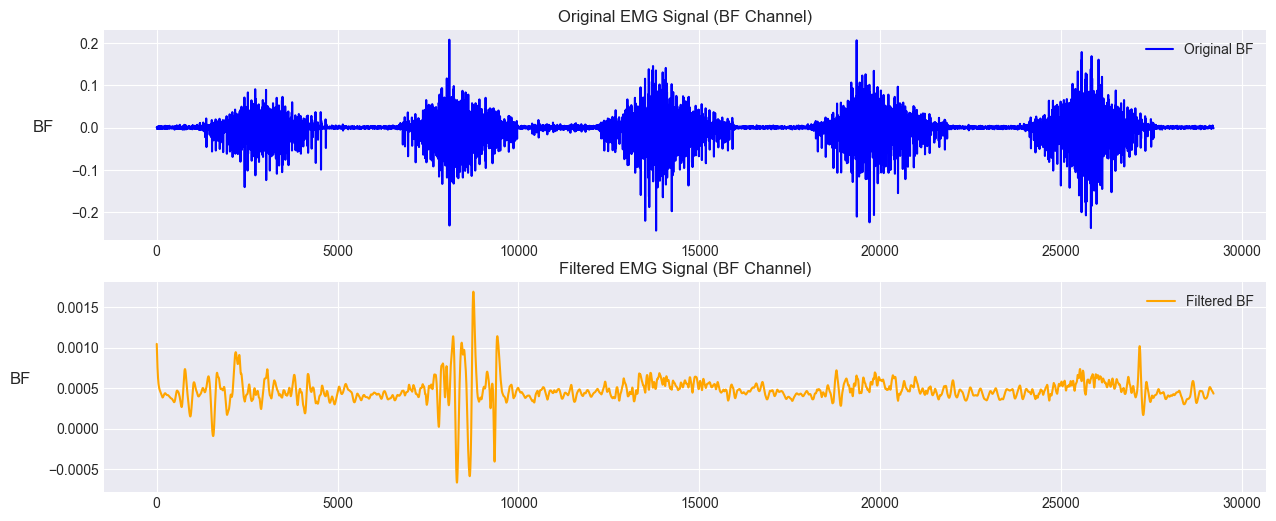

In [335]:
plot_difference(emg, emg_filtered, channel='BF')

#### 4 - Normalize EMG per channel

Its goal is to standardize data, and the benefit is to improve the model’s performance and reduce people’s differences

In [336]:
def normalize_emg(data: np.ndarray, eps: float = 1e-8):
    """Z-score normalize EMG per channel (mean=0, std=1).

    Normalization is performed along the time axis (axis=0):
    - For shape (n_samples,), computes global mean/std.
    - For shape (n_samples, n_channels), computes mean/std per channel.
    """
    mean = np.mean(data, axis=0, keepdims=True)
    std = np.std(data, axis=0, keepdims=True)
    return pd.DataFrame((data - mean) / (std + eps))


In [337]:
emg = load_emg_file(r"N_TXT\1Nsen.txt")
emg_filtered = normalize_emg(emg.values)

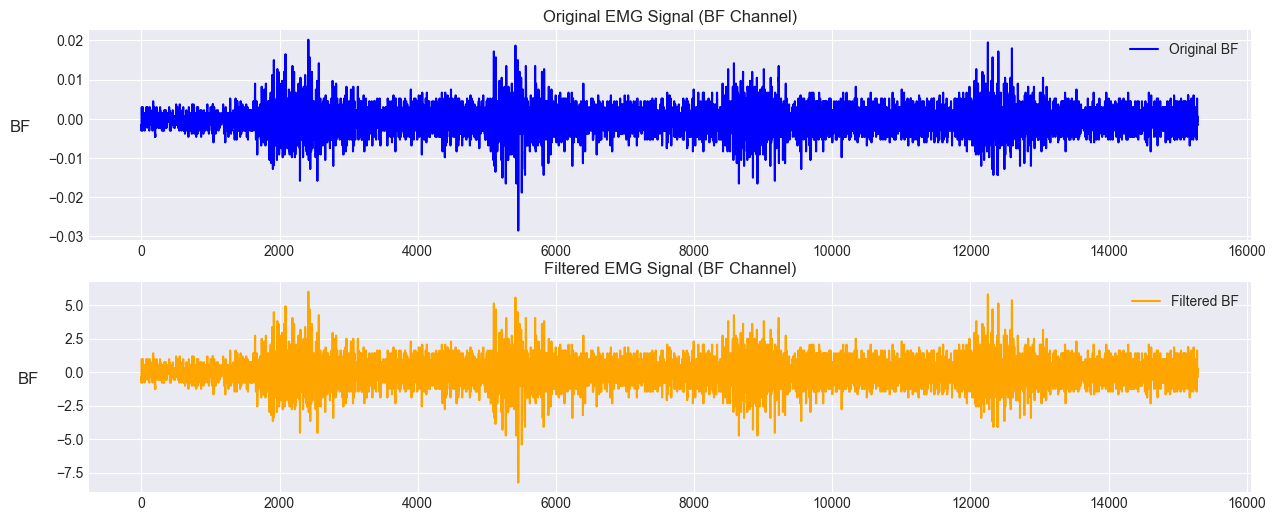

In [338]:
plot_difference(emg, emg_filtered, channel='BF')

#### 5 - Downsample EMG data

 The sampling rate is reduced from 1000 Hz to 100 Hz to improve computational efficiency. 

In [339]:
def downsample_emg(data: np.ndarray, original_fs: float = 1000.0, target_fs: float = 100.0):
    """Downsample EMG data from original_fs to target_fs using decimation (1000 → 100, factor=10)."""

    factor = int(round(original_fs / target_fs))
    if not np.isclose(original_fs / target_fs, factor):
        raise ValueError("original_fs / target_fs must be an integer factor for decimation.")
    downsampled = signal.decimate(data, factor, axis=0, zero_phase=True)
    return pd.DataFrame(downsampled)


In [340]:
emg = load_emg_file(r"N_TXT\1Nsen.txt")
emg_filtered = downsample_emg(emg.values)

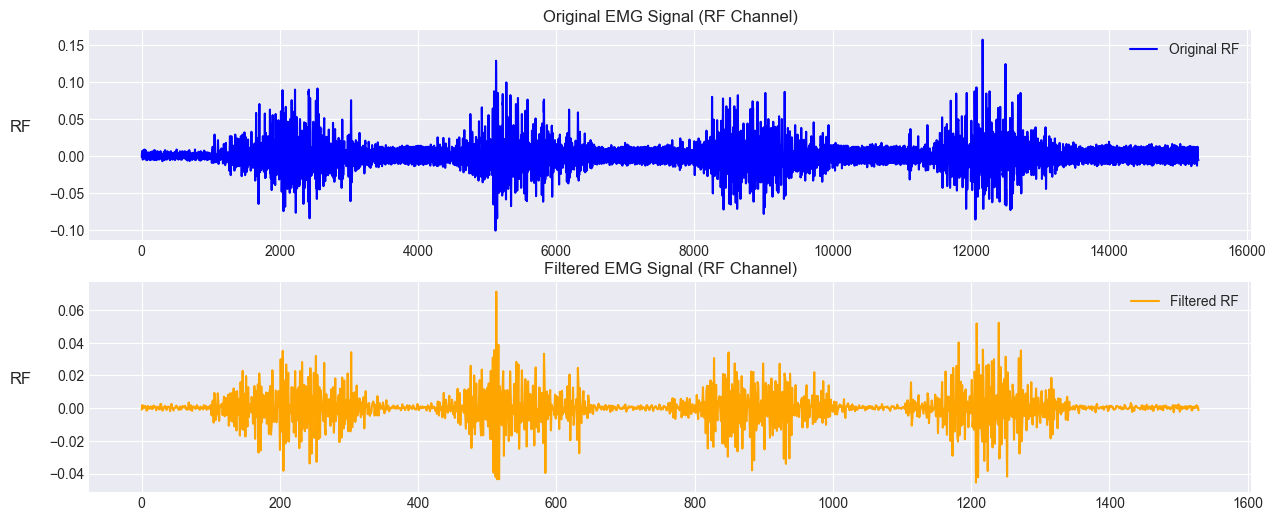

In [341]:
plot_difference(emg, emg_filtered, channel='RF')

In [342]:
def window_signal(data: np.ndarray, window_size: int, overlap: float = 0.0) -> np.ndarray:
    """Segment data into overlapping windows."""
    if not (0.0 <= overlap < 1.0):
        raise ValueError("overlap must be in [0, 1).")

    step = int(window_size * (1.0 - overlap))
    if step <= 0:
        raise ValueError("Step size must be positive. Reduce overlap or window_size.")

    n_samples = data.shape[0]
    indices = []
    start = 0
    while start + window_size <= n_samples:
        indices.append((start, start + window_size))
        start += step

    if len(indices) == 0:
        raise ValueError("Not enough samples for a single window.")

    windows = []
    for start, end in indices:
        segment = data[start:end]
        windows.append(segment)

    return np.stack(windows, axis=0)

In [343]:
emg = load_emg_file(r"N_TXT\1Nsen.txt")
emg_windowed = window_signal(emg.values, window_size=200, overlap=0.5)

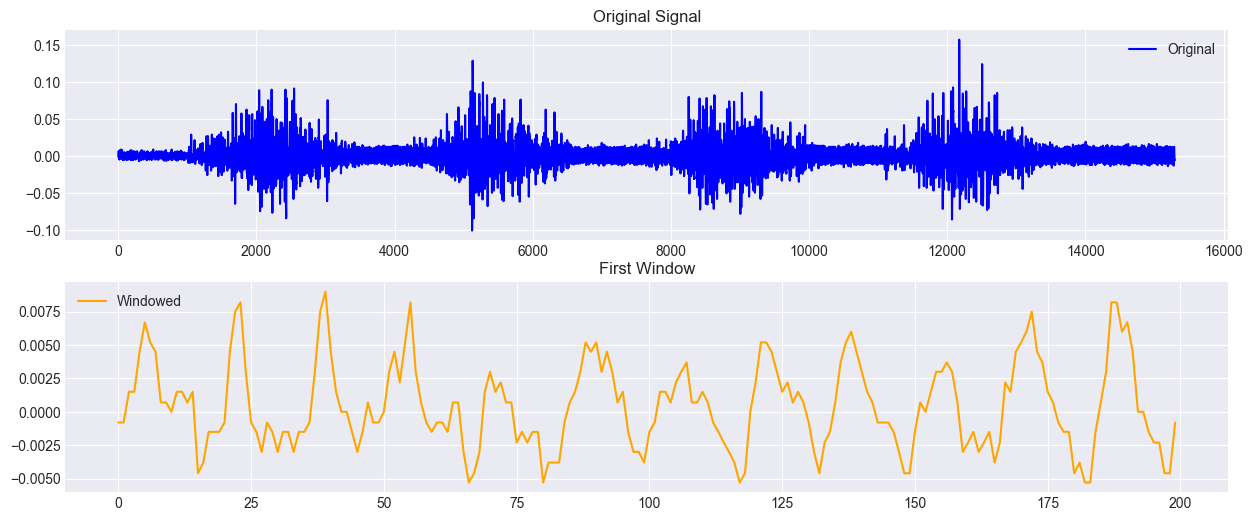

In [344]:
plt.figure(figsize=(15, 6))

# Original
plt.subplot(2, 1, 1)
plt.plot(emg.iloc[:, 0], label='Original', color='blue')
plt.title('Original Signal')
plt.legend()

# Windowed (first window)
plt.subplot(2, 1, 2)
plt.plot(emg_windowed[0][:, 0], label='Windowed', color='orange')
plt.title('First Window')
plt.legend()

plt.show()

### Finally apply the processing pipeline

```plain text
Raw Signal
   ↓
High-pass Filter
   ↓
Rectification
   ↓
Low-pass Filter
   ↓
Normalization
   ↓
Downsampling
   ↓
Model Input

```

In [345]:
def preprocess_emg(
    raw_emg: np.ndarray,
    original_fs: float = 1000.0,
    highpass_cutoff: float = 20.0,
    lowpass_cutoff: float = 4.0,
    lowpass_order: int = 4,
    target_fs: float = 100.0,
    window_size_samples: int = 200,
    window_overlap: float = 0.0,
):
    """Full EMG preprocessing pipeline (clean NumPy version)."""

    # 1. High-pass
    hp = apply_highpass(raw_emg, fs=original_fs, cutoff=highpass_cutoff)

    # 2. Rectify
    rect = np.abs(hp.values)

    # 3. Low-pass
    lp = apply_lowpass(rect, fs=original_fs, cutoff=lowpass_cutoff, order=lowpass_order)

    # 4. Normalize
    mean = np.mean(lp.values, axis=0, keepdims=True)
    std = np.std(lp.values, axis=0, keepdims=True)
    norm = (lp.values - mean) / (std + 1e-8)

    # 5. Downsample
    factor = int(round(original_fs / target_fs))
    downsampled = signal.decimate(norm, factor, axis=0, zero_phase=True)

    # 6. Windowing
    windows = window_signal(downsampled, window_size=window_size_samples, overlap=window_overlap)

    return windows

In [346]:
emg = load_emg_file(r"N_TXT\1Nsen.txt")
windows = preprocess_emg(emg.values, window_overlap=0.5)

print(windows.shape)

(14, 200, 5)


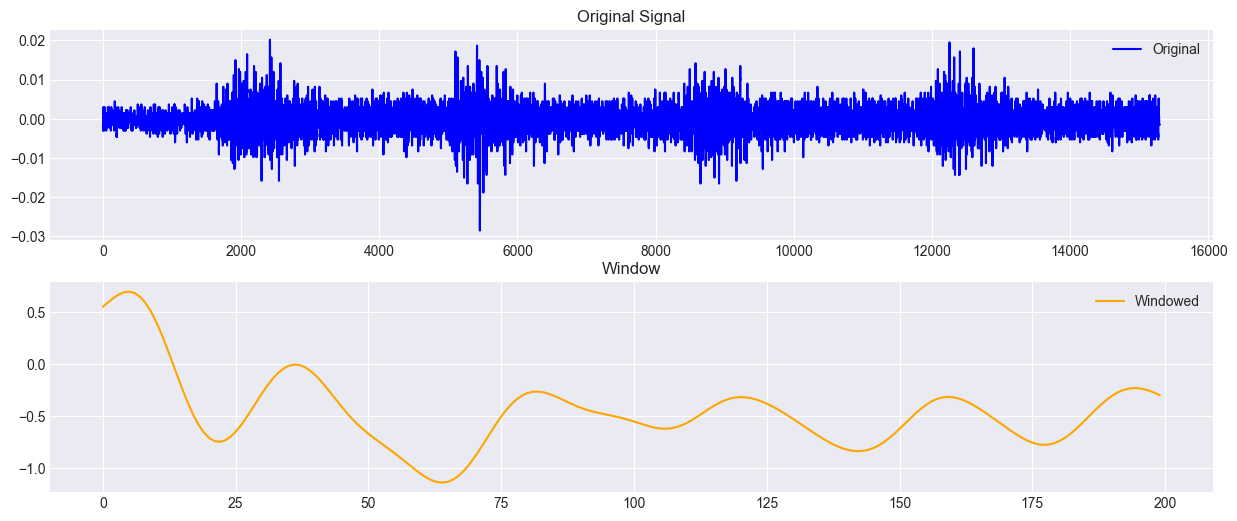

In [347]:
plt.figure(figsize=(15, 6))

# Original
plt.subplot(2, 1, 1)
plt.plot(emg.iloc[:, 1], label='Original', color='blue')
plt.title('Original Signal')
plt.legend()

# Windowed (first window)
plt.subplot(2, 1, 2)
plt.plot(windows[13][:, 1], label='Windowed', color='orange')
plt.title('Window')
plt.legend()

plt.show()

These preprocessing steps are commonly employed 
in studies that predict lower-limb joint angles using EMG signals

### Apply the proessing on entire data

In [348]:
def process_dataset(root_path):
    all_X = []
    all_y = []

    for folder in ["N_TXT", "A_TXT"]:
        folder_path = os.path.join(root_path, folder)

        for file in os.listdir(folder_path):
            if not file.endswith(".txt"):
                continue

            file_path = os.path.join(folder_path, file)

            df = load_emg_file(file_path)

            emg = df.iloc[:, :4].values
            knee = df.iloc[:, 4].values.reshape(-1, 1)

            X = preprocess_emg(emg, window_overlap=0.0)

            # ===== preprocess Knee =====
            factor = int(1000 / 100)
            knee_down = signal.decimate(knee, factor, axis=0, zero_phase=True)

            # windowing
            y = window_signal(knee_down, window_size=200, overlap=0.0)

            all_X.append(X)
            all_y.append(y)

    X = np.concatenate(all_X, axis=0)
    y = np.concatenate(all_y, axis=0)

    return X, y

In [349]:
X, y = process_dataset('.')
print(X.shape, y.shape)

(627, 200, 4) (627, 200, 1)


In [351]:
# save preprocessed data
np.savez("emg_processed_dataset.npz", X=X, y=y)